# Exploratory Data Analysis (EDA)
## Cybersecurity – Detecting Phishing Emails

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the synthetic dataset  to uncover key patterns, feature distributions, missing values, target class imbalance, and feature-target relationships prior to model building.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


### 1. Data Loading & Initial Inspection

In [7]:
# Load dataset
df = pd.read_csv('data/data.csv')

print(f'Dataset Shape: {df.shape}')
print('Columns:', df.columns.tolist())
df.head()


Dataset Shape: (1050, 8)
Columns: ['email_length', 'number_of_links', 'number_of_attachments', 'presence_of_urgent_keywords', 'sender_domain_type', 'html_content_flag', 'email_text', 'phishing_email']


,email_length,number_of_links,number_of_attachments,presence_of_urgent_keywords,sender_domain_type,html_content_flag,email_text,phishing_email
0,1091.99,0.896,0.0864,Absent,Suspicious/Spoofed,Present,Thank you for your payment. Your receipt for i...,Legitimate
1,2110.22,4.020,0.8800,Absent,Trusted/Corporate,Absent,You have received an encrypted document. Click...,Phishing
2,242.89,1.790,0.9080,Absent,Free-Webmail/Common Provider,Present,Your order #94012 has shipped! Track your pack...,Legitimate
3,960.16,1.060,0.0290,Absent,Trusted/Corporate,Present,Thank you for your payment. Your receipt for i...,Legitimate
4,713.57,1.250,0.0415,Absent,Suspicious/Spoofed,Present,Security Advisory: Please be aware of imperson...,Legitimate


In [8]:
# Summary Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   email_length                 1050 non-null   float64
 1   number_of_links              1050 non-null   float64
 2   number_of_attachments        1050 non-null   float64
 3   presence_of_urgent_keywords  1050 non-null   object 
 4   sender_domain_type           1050 non-null   object 
 5   html_content_flag            1050 non-null   object 
 6   email_text                   1050 non-null   object 
 7   phishing_email               1050 non-null   object 
dtypes: float64(3), object(5)
memory usage: 65.8+ KB


In [9]:
# Missing values inspection
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)


Missing values per column:
email_length                   0
number_of_links                0
number_of_attachments          0
presence_of_urgent_keywords    0
sender_domain_type             0
html_content_flag              0
email_text                     0
phishing_email                 0
dtype: int64


### 2. Target Variable & Class Imbalance Analysis

Target Distribution:
Legitimate: 650 (61.90%)
Phishing: 400 (38.10%)


/var/folders/8m/dp01xw5d69q216rlgxsh2s3w0000gn/T/ipykernel_55253/576831027.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='phishing_email', ax=ax[0], palette=['#2ecc71', '#e74c3c'])


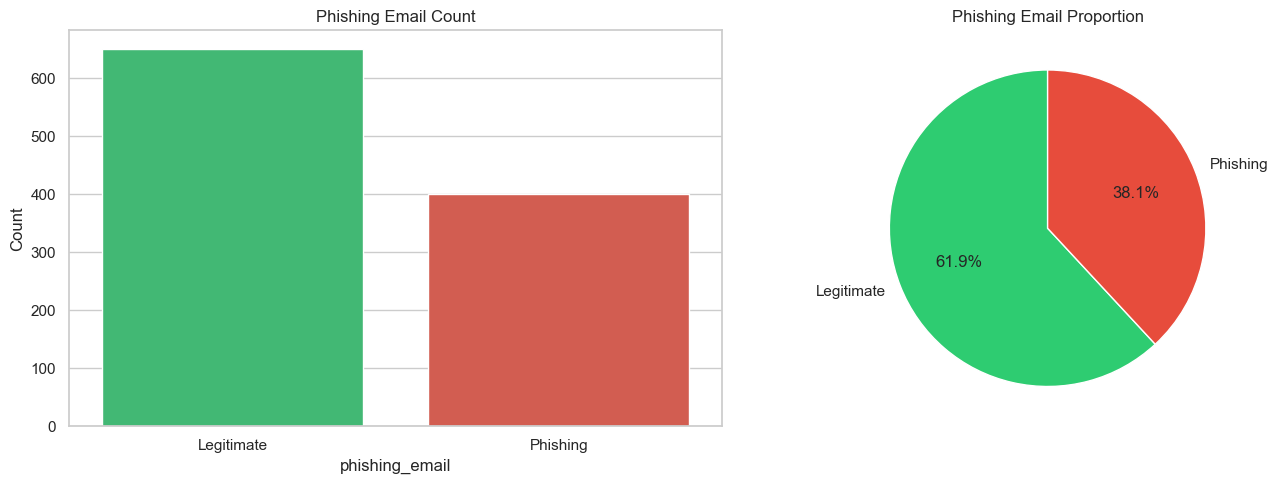

In [10]:
target_counts = df['phishing_email'].value_counts()
target_pct = df['phishing_email'].value_counts(normalize=True) * 100

print('Target Distribution:')
for cls, count in target_counts.items():
    print(f'{cls}: {count} ({target_pct[cls]:.2f}%)')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar Plot
sns.countplot(data=df, x='phishing_email', ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title('Phishing Email Count')
ax[0].set_ylabel('Count')

# Pie Chart
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Phishing Email Proportion')

plt.tight_layout()
plt.show()


### 3. Numerical Features Distribution & Relationship with Target

/var/folders/8m/dp01xw5d69q216rlgxsh2s3w0000gn/T/ipykernel_55253/4262492449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='phishing_email', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
/var/folders/8m/dp01xw5d69q216rlgxsh2s3w0000gn/T/ipykernel_55253/4262492449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='phishing_email', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
/var/folders/8m/dp01xw5d69q216rlgxsh2s3w0000gn/T/ipykernel_55253/4262492449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(dat

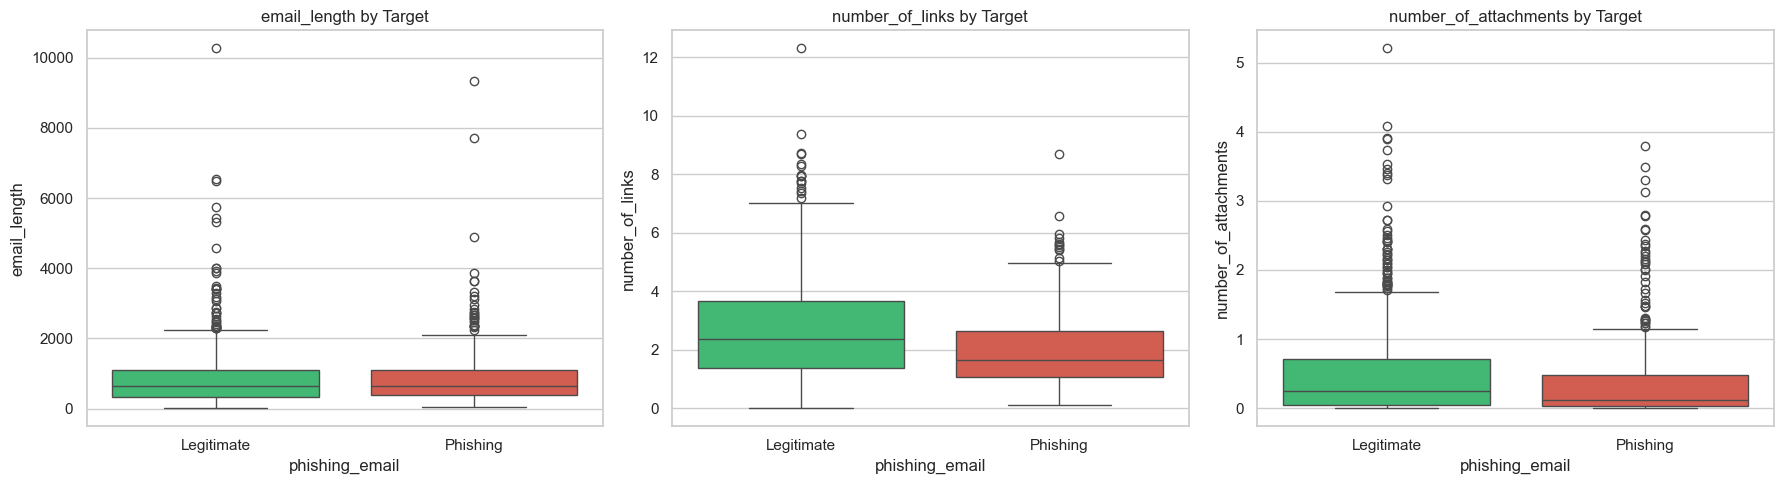

In [11]:
num_cols = ['email_length', 'number_of_links', 'number_of_attachments']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='phishing_email', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Target')

plt.tight_layout()
plt.show()


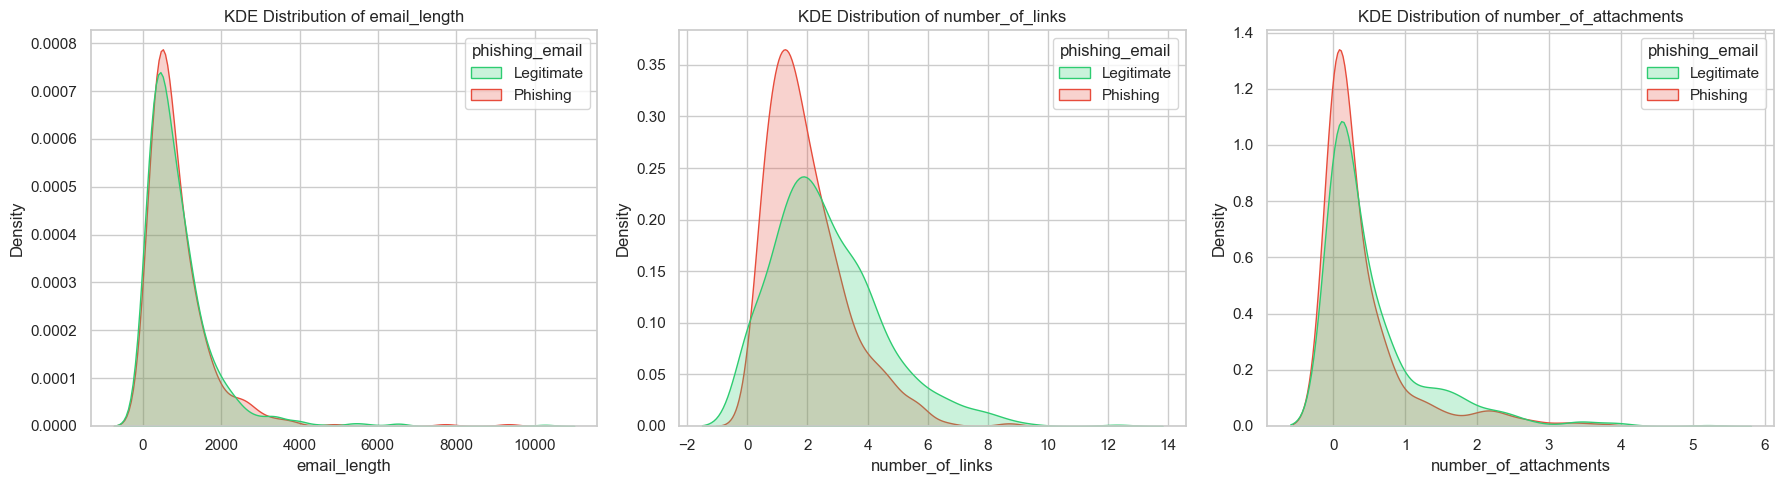

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='phishing_email', ax=axes[i], common_norm=False, fill=True, palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'KDE Distribution of {col}')

plt.tight_layout()
plt.show()


### 4. Categorical Features Analysis

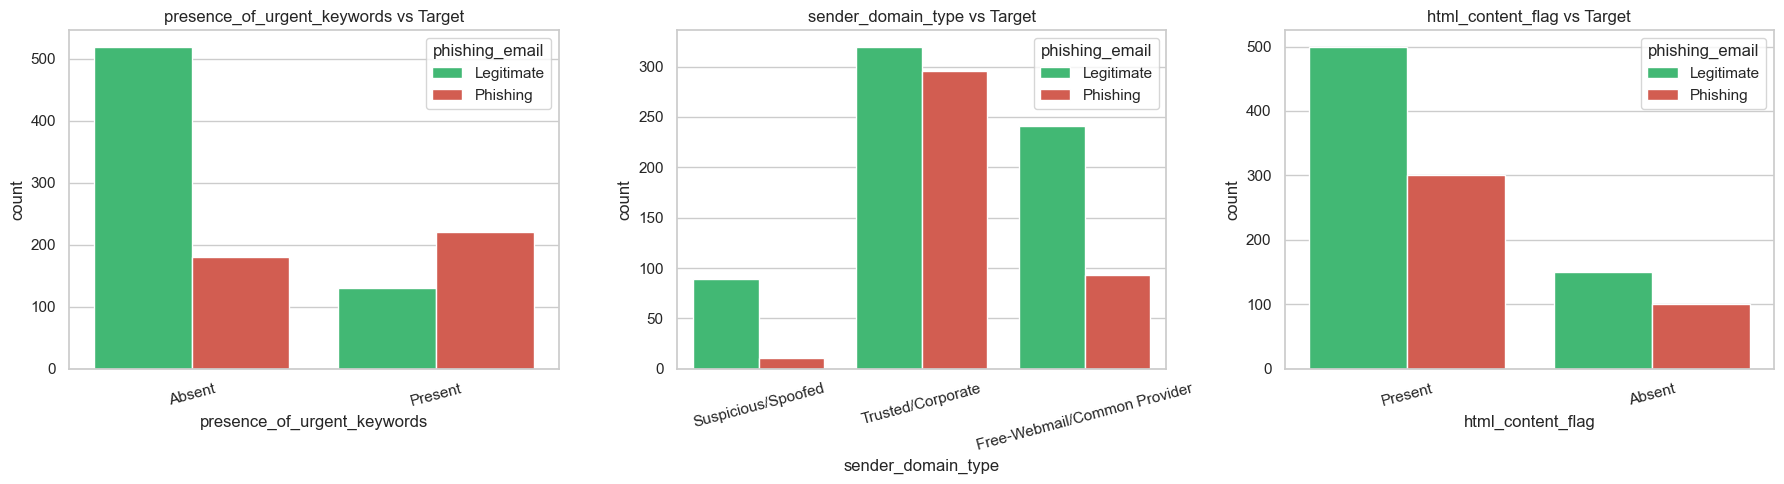

In [13]:
cat_cols = ['presence_of_urgent_keywords', 'sender_domain_type', 'html_content_flag']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='phishing_email', ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Target')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 5. Correlation Heatmap

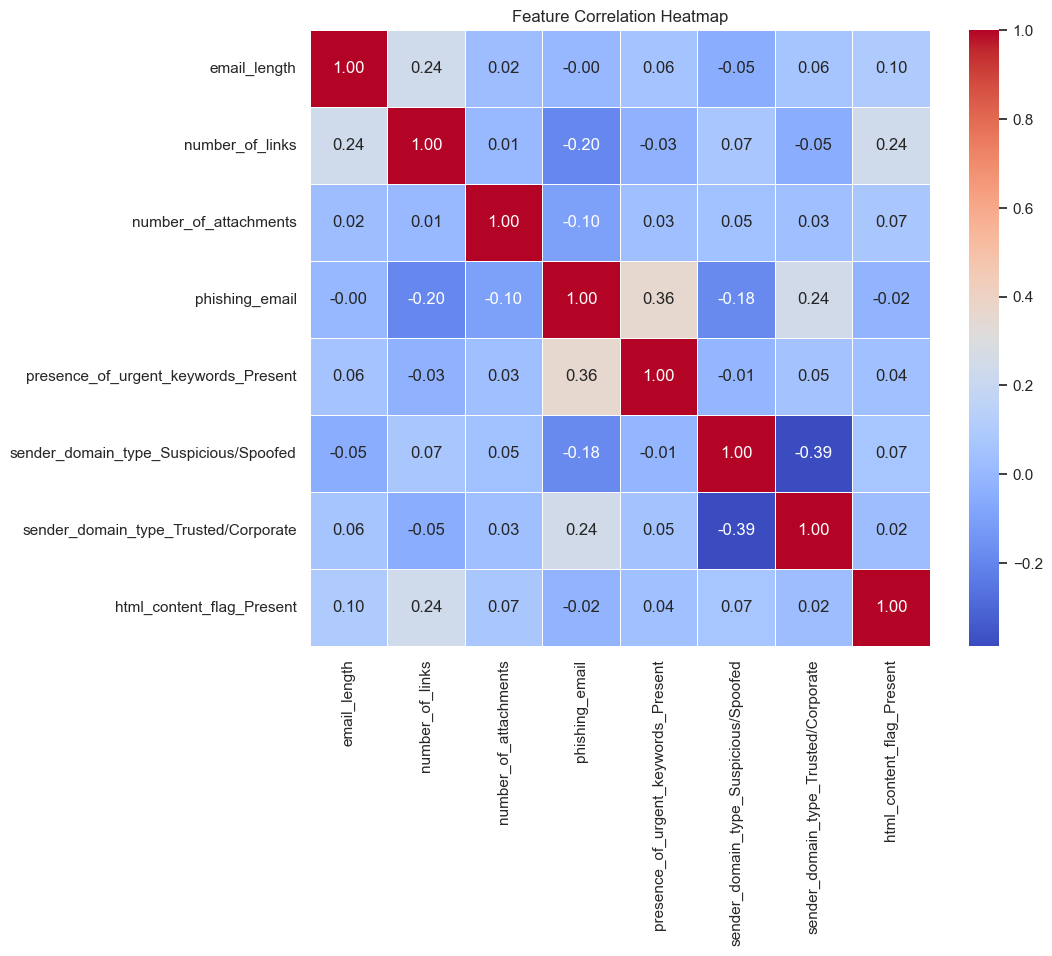

In [14]:
# Drop free-form text column before one-hot encoding for instant correlation
df_tabular = df.drop(columns=['email_text'], errors='ignore').copy()
df_encoded = df_tabular.copy()
df_encoded['phishing_email'] = df_encoded['phishing_email'].map({'Legitimate': 0, 'Phishing': 1})
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### 6. Key Findings & Insights

1. **Target Distribution**: The dataset contains 60% Legitimate emails and 40% Phishing emails.
2. **Sender Domain Type**: Suspicious/Spoofed domains strongly correlate with Phishing emails, whereas Trusted/Corporate domains are predominantly Legitimate.
3. **Urgent Keywords**: Presence of urgent keywords significantly increases the likelihood of phishing.
4. **Number of Links & Attachments**: Phishing emails tend to have a higher average number of links and attachments.
5. **Preprocessing Strategy**:
   - Numerical variables (, , ) should be scaled using .
   - Categorical features should be encoded using .
   - Use stratified splitting and handle potential class imbalance using F1-score optimization and balanced class weighting.
